# Single-Task GRU (SOH) — full 200-epoch baseline

This notebook is the **final STL-SOH baseline protocol** for comparison with MTL.

**Key rule**
- No early stopping.
- Every seed trains for the full `200` epochs.
- The final model for that seed is the checkpoint with the **lowest validation SOH MSE across all 200 epochs**.
- Test data are never used for checkpoint selection.

Everything else remains unchanged from the validated STL-SOH model:
1. Same 10-dim historical input.
2. Same 1-layer GRU encoder + GRUCell decoder + SOH head.
3. Same hidden size, batch size, learning rate, weight decay and dropout.
4. Same battery-level split and leakage check.
5. Same five seeds `[42, 43, 44, 45, 46]`.
6. Same standardized + physical SOH metrics and horizon analysis.

This notebook also saves the full train/validation loss history for all 200 epochs so the best validation epoch can be audited directly.


In [1]:
import sys
import torch
import numpy as np
import pandas as pd

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

print(torch.rand(2, 3))


Python: d:\venvs\torch_test\Scripts\python.exe
PyTorch: 2.8.0+cpu
NumPy: 2.5.3
Pandas: 3.0.5
tensor([[0.8070, 0.2543, 0.9995],
        [0.3346, 0.3811, 0.3279]])


In [2]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEEDS = [42, 43, 44, 45, 46]
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
print('seeds:', SEEDS)

# Keep the original STL-SOH hyperparameters unchanged.
HID          = 64
ENC_LAYERS   = 1
DROPOUT      = 0.2
LR           = 3e-3
WEIGHT_DECAY = 1e-4
EPOCHS       = 200
BATCH_SIZE   = 32

# No PATIENCE: every seed runs all 200 epochs.
TRAIN_EVAL_BATCH = 256


device: cpu
seeds: [42, 43, 44, 45, 46]


In [3]:
# ---- load data + scaler ----
DATA_CANDIDATES   = [Path('seq_dataset_10dim_v7.npz'), Path('/mnt/data/seq_dataset_10dim_v7.npz')]
SCALER_CANDIDATES = [Path('scaler_10dim_v7.json'),     Path('/mnt/data/scaler_10dim_v7.json')]
DATA_PATH   = next((p for p in DATA_CANDIDATES if p.exists()), None)
SCALER_PATH = next((p for p in SCALER_CANDIDATES if p.exists()), None)

if DATA_PATH is None or SCALER_PATH is None:
    raise FileNotFoundError('请把 seq_dataset_10dim_v7.npz 和 scaler_10dim_v7.json 放到同目录或 /mnt/data/。')

data = np.load(DATA_PATH, allow_pickle=True)
features = data['features'].tolist()
SOH_IDX = features.index('SOH')
F = len(features)

cfg = json.load(open(SCALER_PATH, encoding='utf-8'))
assert cfg['features'] == features, 'scaler 与数据集特征顺序不一致'
SOH_MEAN = float(np.asarray(cfg['mean'], float)[SOH_IDX])
SOH_STD  = float(np.asarray(cfg['std'],  float)[SOH_IDX])

def soh_to_physical(x):
    return np.asarray(x, float) * SOH_STD + SOH_MEAN

def get(split):
    X = np.where(
        data[f'{split}_X_fmask'].astype(bool),
        data[f'{split}_X'].astype(np.float32),
        0.0
    )
    Xt = data[f'{split}_X_tmask'].astype(bool)
    Y = data[f'{split}_Y'][:, :, SOH_IDX].astype(np.float32)
    Ym = data[f'{split}_Y_mask'][:, :, SOH_IDX].astype(bool)
    bid = data[f'{split}_bid']
    return X.astype(np.float32), Xt, Y, Ym, bid

Xtr, Xttr, Ytr, Ymtr, btr = get('train')
Xva, Xtva, Yva, Ymva, bva = get('val')
Xte, Xtte, Yte, Ymte, bte = get('test')
HORIZON = Ytr.shape[1]

utr, uva, ute = np.unique(btr), np.unique(bva), np.unique(bte)

print('features:', features)
print(f'SOH mean/std: {SOH_MEAN:.6f} / {SOH_STD:.6f}')
print('sample/window counts:', len(btr), len(bva), len(bte))
print('unique battery counts:', len(utr), len(uva), len(ute))
print('horizon:', HORIZON)

assert np.intersect1d(utr, uva).size == 0, 'Leakage: train and val share battery IDs'
assert np.intersect1d(utr, ute).size == 0, 'Leakage: train and test share battery IDs'
assert np.intersect1d(uva, ute).size == 0, 'Leakage: val and test share battery IDs'

print('Battery leakage check passed.')


features: ['SOH', 'SOC10_R0', 'SOC50_R0', 'SOC90_R0', 'SOC10_R1', 'SOC50_R1', 'SOC90_R1', 'SOC10_R2', 'SOC50_R2', 'SOC90_R2']
SOH mean/std: 78.513546 / 10.497872
sample/window counts: 4581 45 45
unique battery counts: 212 45 45
horizon: 29
Battery leakage check passed.


In [4]:
# ---- model: shared encoder + single SOH head (MTL-ready) ----
class GRUSeq2Seq(nn.Module):
    def __init__(self, in_dim, hid=64, layers=1, tasks=('SOH',), horizon=29, p=0.2):
        super().__init__()
        self.encoder  = nn.GRU(in_dim, hid, layers, batch_first=True,
                               dropout=p if layers > 1 else 0.0)
        self.dec_cell = nn.GRUCell(hid, hid)
        self.drop     = nn.Dropout(p)
        self.heads    = nn.ModuleDict({t: nn.Linear(hid, 1) for t in tasks})
        self.horizon  = horizon

    def forward(self, x, x_tmask):
        lengths = x_tmask.sum(1).clamp(min=1).cpu()
        packed  = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True,
                                                    enforce_sorted=False)
        _, h = self.encoder(packed)
        s = h[-1]                        # (B, hid) last-layer encoder state
        z = torch.zeros_like(s)
        outs = {t: [] for t in self.heads}
        for _ in range(self.horizon):    # unroll decoder
            s = self.dec_cell(z, s)
            sd = self.drop(s)
            for t, head in self.heads.items():
                outs[t].append(head(sd))
            z = s
        return {t: torch.cat(v, 1) for t, v in outs.items()}   # each (B, horizon)

def masked_mse(pred, y, m):
    m = m.float()
    return ((pred - y) ** 2 * m).sum() / m.sum().clamp(min=1)

seed=42 | epoch=  1/200 | train=0.130256 | val=0.175201 | best=0.175201 @ 1
seed=42 | epoch= 20/200 | train=0.090687 | val=0.089176 | best=0.045495 @ 11
seed=42 | epoch= 40/200 | train=0.037773 | val=0.041861 | best=0.036064 @ 35
seed=42 | epoch= 60/200 | train=0.032579 | val=0.040657 | best=0.034552 @ 54
seed=42 | epoch= 80/200 | train=0.030881 | val=0.053690 | best=0.034366 @ 73
seed=42 | epoch=100/200 | train=0.022097 | val=0.046736 | best=0.034366 @ 73
seed=42 | epoch=120/200 | train=0.023105 | val=0.051460 | best=0.034366 @ 73
seed=42 | epoch=140/200 | train=0.022905 | val=0.059492 | best=0.034366 @ 73
seed=42 | epoch=160/200 | train=0.017594 | val=0.053940 | best=0.034366 @ 73
seed=42 | epoch=180/200 | train=0.021252 | val=0.050880 | best=0.034366 @ 73
seed=42 | epoch=200/200 | train=0.024031 | val=0.060078 | best=0.034366 @ 73
FINAL seed=42 | best val SOH MSE=0.034366 | best epoch=73 | trained=200
seed=43 | epoch=  1/200 | train=0.112380 | val=0.132432 | best=0.132432 @ 1
seed=4

,seed,best_val_SOH_MSE_std,best_epoch,epochs_trained
0,42,0.034366,73,200
1,43,0.034406,113,200
2,44,0.025842,178,200
3,45,0.024412,91,200
4,46,0.033616,79,200


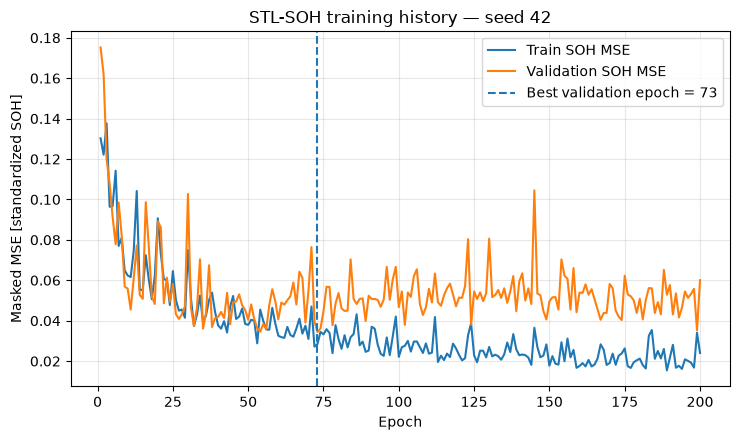

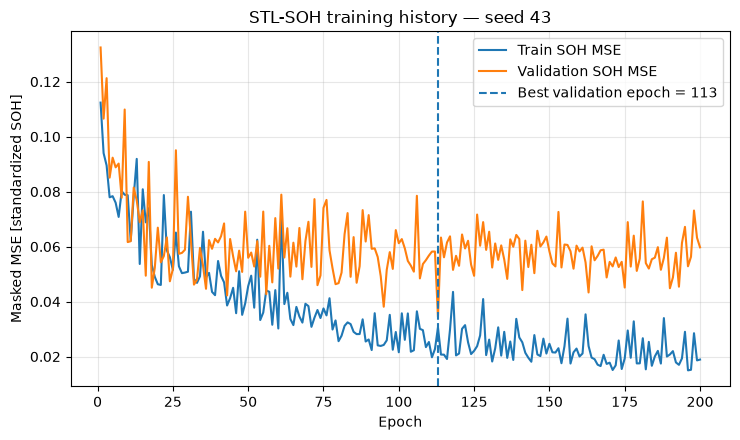

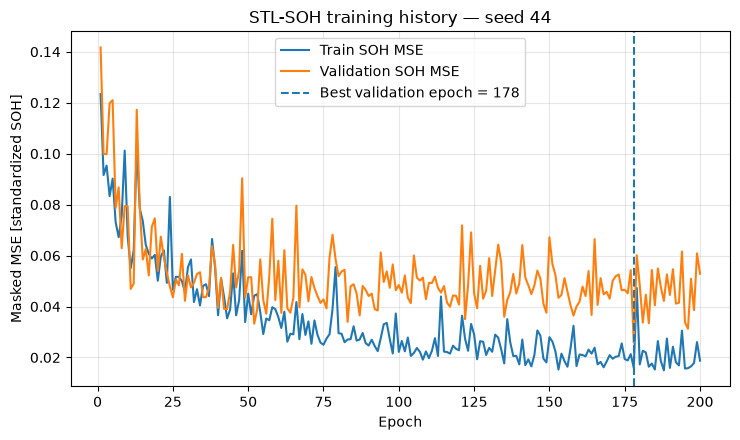

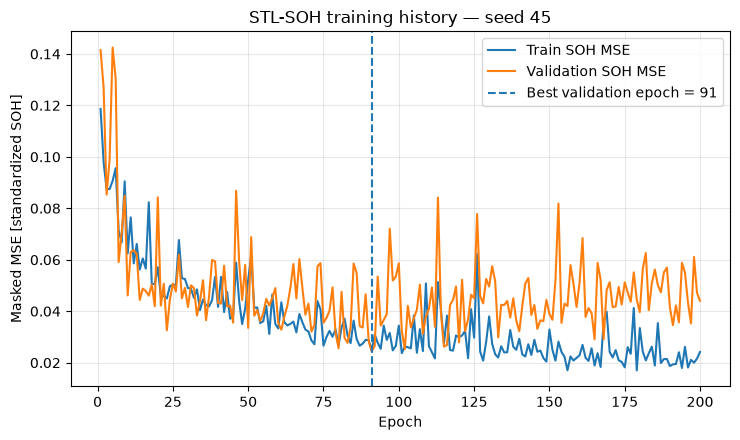

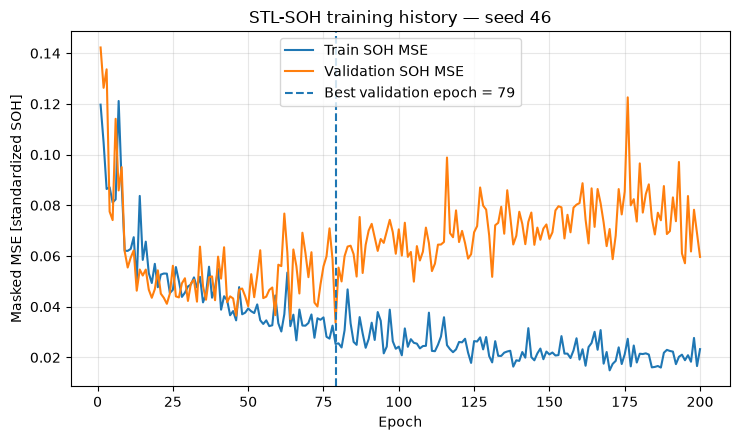

In [5]:
# ---- full 200-epoch training for five seeds ----
def to_t(*a):
    return [torch.tensor(x).to(DEVICE) for x in a]

xtr, xttr, ytr, ymtr = to_t(Xtr, Xttr, Ytr, Ymtr)
xva, xtva, yva, ymva = to_t(Xva, Xtva, Yva, Ymva)
xte, xtte, yte, ymte = to_t(Xte, Xtte, Yte, Ymte)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def exact_masked_mse_in_batches(model, x, xt, y, ym, batch_size=256):
    """Exact global masked MSE evaluated in batches."""
    model.eval()
    sse = 0.0
    n_valid = 0.0

    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            xb = x[i:i+batch_size]
            xtb = xt[i:i+batch_size]
            yb = y[i:i+batch_size]
            mb = ym[i:i+batch_size].float()

            pred = model(xb, xtb)['SOH']
            sse += float((((pred - yb) ** 2) * mb).sum().item())
            n_valid += float(mb.sum().item())

    return sse / max(n_valid, 1.0)

def train_one_seed(seed):
    set_seed(seed)

    model = GRUSeq2Seq(
        F,
        hid=HID,
        layers=ENC_LAYERS,
        tasks=('SOH',),
        horizon=HORIZON,
        p=DROPOUT
    ).to(DEVICE)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    best_val = math.inf
    best_state = None
    best_epoch = None
    history = []
    N = len(xtr)

    # IMPORTANT: run every epoch; there is no early-stopping break.
    for ep in range(1, EPOCHS + 1):
        model.train()
        perm = torch.randperm(N)

        for i in range(0, N, BATCH_SIZE):
            idx = perm[i:i+BATCH_SIZE]

            opt.zero_grad()
            pred = model(xtr[idx], xttr[idx])['SOH']
            loss = masked_mse(pred, ytr[idx], ymtr[idx])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # Record exact epoch-end train and validation SOH MSE.
        train_mse = exact_masked_mse_in_batches(
            model, xtr, xttr, ytr, ymtr,
            batch_size=TRAIN_EVAL_BATCH
        )
        val_mse = exact_masked_mse_in_batches(
            model, xva, xtva, yva, ymva,
            batch_size=TRAIN_EVAL_BATCH
        )

        improved = val_mse < best_val - 1e-6
        if improved:
            best_val = val_mse
            best_epoch = ep
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        history.append({
            'seed': seed,
            'epoch': ep,
            'train_SOH_MSE_std': train_mse,
            'val_SOH_MSE_std': val_mse,
            'is_best_so_far': bool(improved),
        })

        if ep == 1 or ep % 20 == 0 or ep == EPOCHS:
            print(
                f"seed={seed} | epoch={ep:3d}/{EPOCHS} "
                f"| train={train_mse:.6f} | val={val_mse:.6f} "
                f"| best={best_val:.6f} @ {best_epoch}"
            )

    # For the final evaluation, restore the validation-best checkpoint
    # selected from the entire 1..200 epoch range.
    model.load_state_dict(best_state)

    info = {
        'seed': seed,
        'best_val_SOH_MSE_std': best_val,
        'best_epoch': best_epoch,
        'epochs_trained': EPOCHS,
    }
    return model, info, history

models = {}
training_rows = []
history_rows = []

for seed in SEEDS:
    model_seed, info, hist = train_one_seed(seed)
    models[seed] = model_seed
    training_rows.append(info)
    history_rows.extend(hist)

    print(
        f"FINAL seed={seed} | best val SOH MSE={info['best_val_SOH_MSE_std']:.6f} "
        f"| best epoch={info['best_epoch']} | trained={info['epochs_trained']}"
    )

training_summary = pd.DataFrame(training_rows)
training_history = pd.DataFrame(history_rows)

print('\nValidation-best checkpoint for each seed:')
display(training_summary)

# Diagnostic curves: one separate figure per seed.
for seed in SEEDS:
    d = training_history[training_history['seed'] == seed]
    best_ep = int(training_summary.loc[
        training_summary['seed'] == seed, 'best_epoch'
    ].iloc[0])

    plt.figure(figsize=(7.5, 4.5))
    plt.plot(d['epoch'], d['train_SOH_MSE_std'], label='Train SOH MSE')
    plt.plot(d['epoch'], d['val_SOH_MSE_std'], label='Validation SOH MSE')
    plt.axvline(best_ep, linestyle='--', label=f'Best validation epoch = {best_ep}')
    plt.xlabel('Epoch')
    plt.ylabel('Masked MSE [standardized SOH]')
    plt.title(f'STL-SOH training history — seed {seed}')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [6]:
# ---- evaluate five seeds on standardized and physical scales ----
def predict(model, x, xt):
    model.eval()
    with torch.no_grad():
        return model(x, xt)['SOH'].cpu().numpy()

def evaluate(seed, split, pred_std, Y, Ym, bid):
    rows = []

    for i in range(len(Y)):
        for h in np.flatnonzero(Ym[i]):
            yt_std = float(Y[i, h])
            yp_std = float(pred_std[i, h])
            yt_phys = float(soh_to_physical(yt_std))
            yp_phys = float(soh_to_physical(yp_std))

            rows.append({
                'seed': seed,
                'split': split,
                'bid': int(bid[i]),
                'horizon': int(h) + 1,
                'yt_std': yt_std,
                'yp_std': yp_std,
                'yt_phys': yt_phys,
                'yp_phys': yp_phys,
                'abs_std': abs(yp_std - yt_std),
                'sq_std': (yp_std - yt_std) ** 2,
                'abs_phys': abs(yp_phys - yt_phys),
                'sq_phys': (yp_phys - yt_phys) ** 2,
                'ape_phys': abs(yp_phys - yt_phys) / abs(yt_phys) * 100.0,
            })

    df = pd.DataFrame(rows)

    # standardized pooled metrics
    pooled_mae_std = df['abs_std'].mean()
    pooled_rmse_std = math.sqrt(df['sq_std'].mean())

    ss_res_std = ((df['yp_std'] - df['yt_std']) ** 2).sum()
    ss_tot_std = ((df['yt_std'] - df['yt_std'].mean()) ** 2).sum()
    r2_std = 1 - ss_res_std / ss_tot_std if ss_tot_std > 0 else float('nan')

    # physical pooled metrics
    pooled_mae_phys = df['abs_phys'].mean()
    pooled_rmse_phys = math.sqrt(df['sq_phys'].mean())

    ss_res_phys = ((df['yp_phys'] - df['yt_phys']) ** 2).sum()
    ss_tot_phys = ((df['yt_phys'] - df['yt_phys'].mean()) ** 2).sum()
    r2_phys = 1 - ss_res_phys / ss_tot_phys if ss_tot_phys > 0 else float('nan')

    # true macro-over-batteries aggregation
    per_cell = (
        df.groupby('bid')
          .agg(
              mae_std=('abs_std', 'mean'),
              mae_phys=('abs_phys', 'mean'),
              mape_phys=('ape_phys', 'mean'),
          )
    )

    return {
        'seed': seed,
        'split': split,
        'MAE macro [std]': per_cell['mae_std'].mean(),
        'MAE pooled [std]': pooled_mae_std,
        'RMSE pooled [std]': pooled_rmse_std,
        'R2 pooled [std]': r2_std,
        'MAE macro [%SOH]': per_cell['mae_phys'].mean(),
        'MAE pooled [%SOH]': pooled_mae_phys,
        'RMSE pooled [%SOH]': pooled_rmse_phys,
        'R2 pooled [physical]': r2_phys,
        'MAPE macro [%]': per_cell['mape_phys'].mean(),
        'N cells': int(df['bid'].nunique()),
        'N points': int(len(df)),
    }, df

result_rows = []
point_tables = []

for seed in SEEDS:
    pred_val = predict(models[seed], xva, xtva)
    pred_test = predict(models[seed], xte, xtte)

    rv, dv = evaluate(seed, 'val', pred_val, Yva, Ymva, bva)
    rt, dt = evaluate(seed, 'test', pred_test, Yte, Ymte, bte)

    result_rows.extend([rv, rt])
    point_tables.extend([dv, dt])

res_seeds = pd.DataFrame(result_rows)
points_all = pd.concat(point_tables, ignore_index=True)

metric_cols = [
    'MAE macro [std]',
    'MAE pooled [std]',
    'RMSE pooled [std]',
    'R2 pooled [std]',
    'MAE macro [%SOH]',
    'MAE pooled [%SOH]',
    'RMSE pooled [%SOH]',
    'R2 pooled [physical]',
    'MAPE macro [%]',
]

summary_rows = []
for split in ['val', 'test']:
    d = res_seeds[res_seeds['split'] == split]
    row = {'split': split}
    for col in metric_cols:
        row[f'{col} mean'] = d[col].mean()
        row[f'{col} std'] = d[col].std(ddof=1)
    row['N seeds'] = d['seed'].nunique()
    row['N cells'] = int(d['N cells'].iloc[0])
    row['N points'] = int(d['N points'].iloc[0])
    summary_rows.append(row)

res_summary = pd.DataFrame(summary_rows).set_index('split')

print('Per-seed results:')
display(res_seeds.round(4))

print('\nFive-seed mean ± std summary:')
display(res_summary.round(4))


Per-seed results:


,seed,split,MAE macro [std],MAE pooled [std],RMSE pooled [std],R2 pooled [std],MAE macro [%SOH],MAE pooled [%SOH],RMSE pooled [%SOH],R2 pooled [physical],MAPE macro [%],N cells,N points
0,42,val,0.1029,0.1050,0.1854,0.9427,1.0804,1.1021,1.9461,0.9427,1.5579,45,662
1,42,test,0.0929,0.0950,0.1588,0.9547,0.9755,0.9973,1.6667,0.9547,1.3526,45,622
2,43,val,0.1093,0.1105,0.1855,0.9426,1.1475,1.1601,1.9472,0.9426,1.6361,45,662
3,43,test,0.1030,0.1061,0.1783,0.9429,1.0813,1.1143,1.8715,0.9429,1.5256,45,622
4,44,val,0.0843,0.0813,0.1608,0.9569,0.8845,0.8532,1.6876,0.9569,1.2597,45,662
5,44,test,0.1021,0.0992,0.1936,0.9326,1.0717,1.0412,2.0325,0.9326,1.4705,45,622
6,45,val,0.0938,0.0951,0.1562,0.9593,0.9843,0.9986,1.6402,0.9593,1.3920,45,662
7,45,test,0.0860,0.0867,0.1527,0.9581,0.9033,0.9103,1.6033,0.9581,1.2553,45,622
8,46,val,0.1008,0.1025,0.1833,0.9439,1.0582,1.0762,1.9247,0.9439,1.5250,45,662
9,46,test,0.0992,0.1009,0.1529,0.9580,1.0409,1.0597,1.6052,0.9580,1.4661,45,622



Five-seed mean ± std summary:


,MAE macro [std] mean,MAE macro [std] std,MAE pooled [std] mean,MAE pooled [std] std,RMSE pooled [std] mean,RMSE pooled [std] std,R2 pooled [std] mean,R2 pooled [std] std,MAE macro [%SOH] mean,MAE macro [%SOH] std,...,MAE pooled [%SOH] std,RMSE pooled [%SOH] mean,RMSE pooled [%SOH] std,R2 pooled [physical] mean,R2 pooled [physical] std,MAPE macro [%] mean,MAPE macro [%] std,N seeds,N cells,N points
split,,,,,,,,,,,,,,,,,,,,,
val,0.0982,0.0096,0.0989,0.0113,0.1742,0.0145,0.9491,0.0083,1.0310,0.1005,...,0.1185,1.8292,0.1521,0.9491,0.0083,1.4742,0.1488,5,45,662
test,0.0966,0.0071,0.0976,0.0073,0.1673,0.0181,0.9493,0.0112,1.0145,0.0747,...,0.0764,1.7558,0.1896,0.9493,0.0112,1.4140,0.1087,5,45,622


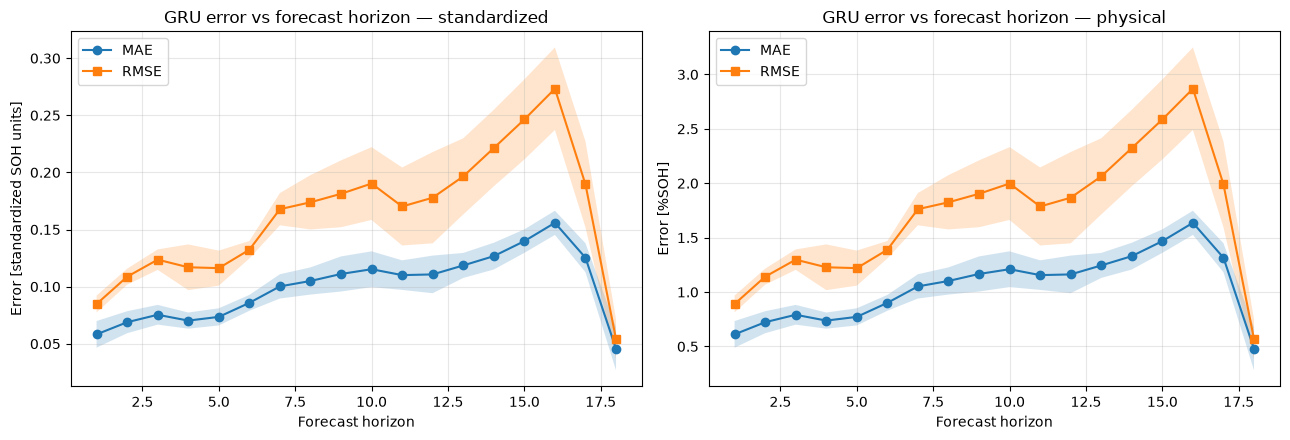

,horizon,MAE_std_mean,MAE_std_std,RMSE_std_mean,RMSE_std_std,MAE_phys_mean,MAE_phys_std,RMSE_phys_mean,RMSE_phys_std,N
0,1,0.0582,0.0117,0.0848,0.0074,0.6112,0.1225,0.8902,0.0773,45
1,2,0.0688,0.0096,0.1087,0.0070,0.7227,0.1012,1.1411,0.0737,45
2,3,0.0754,0.0086,0.1236,0.0089,0.7913,0.0908,1.2978,0.0939,45
3,4,0.0703,0.0071,0.1170,0.0200,0.7376,0.0743,1.2278,0.2101,42
4,5,0.0735,0.0075,0.1162,0.0154,0.7719,0.0789,1.2198,0.1612,42
5,6,0.0858,0.0069,0.1323,0.0077,0.9007,0.0729,1.3890,0.0805,42
6,7,0.1002,0.0106,0.1678,0.0141,1.0521,0.1117,1.7618,0.1483,42
7,8,0.1050,0.0119,0.1738,0.0238,1.1018,0.1250,1.8251,0.2496,42
8,9,0.1111,0.0154,0.1813,0.0293,1.1661,0.1614,1.9030,0.3072,41
9,10,0.1153,0.0157,0.1903,0.0319,1.2099,0.1646,1.9973,0.3347,41


In [7]:
# ---- forecast-horizon curves: five-seed mean ± std ----
test_points = points_all[points_all['split'] == 'test'].copy()

per_seed_h = (
    test_points.groupby(['seed', 'horizon'])
    .agg(
        MAE_std=('abs_std', 'mean'),
        RMSE_std=('sq_std', lambda s: math.sqrt(s.mean())),
        MAE_phys=('abs_phys', 'mean'),
        RMSE_phys=('sq_phys', lambda s: math.sqrt(s.mean())),
        N=('yt_std', 'size')
    )
    .reset_index()
)

hz = (
    per_seed_h.groupby('horizon')
    .agg(
        MAE_std_mean=('MAE_std', 'mean'),
        MAE_std_std=('MAE_std', 'std'),
        RMSE_std_mean=('RMSE_std', 'mean'),
        RMSE_std_std=('RMSE_std', 'std'),
        MAE_phys_mean=('MAE_phys', 'mean'),
        MAE_phys_std=('MAE_phys', 'std'),
        RMSE_phys_mean=('RMSE_phys', 'mean'),
        RMSE_phys_std=('RMSE_phys', 'std'),
        N=('N', 'first')
    )
    .reset_index()
)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(hz['horizon'], hz['MAE_std_mean'], marker='o', label='MAE')
ax[0].fill_between(
    hz['horizon'],
    hz['MAE_std_mean'] - hz['MAE_std_std'],
    hz['MAE_std_mean'] + hz['MAE_std_std'],
    alpha=0.2
)
ax[0].plot(hz['horizon'], hz['RMSE_std_mean'], marker='s', label='RMSE')
ax[0].fill_between(
    hz['horizon'],
    hz['RMSE_std_mean'] - hz['RMSE_std_std'],
    hz['RMSE_std_mean'] + hz['RMSE_std_std'],
    alpha=0.2
)
ax[0].set_xlabel('Forecast horizon')
ax[0].set_ylabel('Error [standardized SOH units]')
ax[0].set_title('GRU error vs forecast horizon — standardized')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(hz['horizon'], hz['MAE_phys_mean'], marker='o', label='MAE')
ax[1].fill_between(
    hz['horizon'],
    hz['MAE_phys_mean'] - hz['MAE_phys_std'],
    hz['MAE_phys_mean'] + hz['MAE_phys_std'],
    alpha=0.2
)
ax[1].plot(hz['horizon'], hz['RMSE_phys_mean'], marker='s', label='RMSE')
ax[1].fill_between(
    hz['horizon'],
    hz['RMSE_phys_mean'] - hz['RMSE_phys_std'],
    hz['RMSE_phys_mean'] + hz['RMSE_phys_std'],
    alpha=0.2
)
ax[1].set_xlabel('Forecast horizon')
ax[1].set_ylabel('Error [%SOH]')
ax[1].set_title('GRU error vs forecast horizon — physical')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

hz.round(4)


In [8]:
# ---- save full-200 STL-SOH outputs ----
prefix = 'stl_soh_full200'

training_history.to_csv(
    f'{prefix}_training_history_5seeds.csv',
    index=False
)
training_summary.to_csv(
    f'{prefix}_training_summary_5seeds.csv',
    index=False
)

points_all.to_csv(
    f'{prefix}_predictions_5seeds.csv',
    index=False
)
res_seeds.to_csv(
    f'{prefix}_metrics_per_seed.csv',
    index=False
)
res_summary.to_csv(
    f'{prefix}_metrics_5seed_summary.csv'
)
hz.to_csv(
    f'{prefix}_horizon_5seed_summary.csv',
    index=False
)

print(f'saved {prefix}_training_history_5seeds.csv')
print(f'saved {prefix}_training_summary_5seeds.csv')
print(f'saved {prefix}_predictions_5seeds.csv')
print(f'saved {prefix}_metrics_per_seed.csv')
print(f'saved {prefix}_metrics_5seed_summary.csv')
print(f'saved {prefix}_horizon_5seed_summary.csv')


saved stl_soh_full200_training_history_5seeds.csv
saved stl_soh_full200_training_summary_5seeds.csv
saved stl_soh_full200_predictions_5seeds.csv
saved stl_soh_full200_metrics_per_seed.csv
saved stl_soh_full200_metrics_5seed_summary.csv
saved stl_soh_full200_horizon_5seed_summary.csv


## Baseline interpretation

For each seed, this notebook trains **all 200 epochs** and selects exactly one checkpoint:

\[
e^* = \arg\min_{e\in\{1,\dots,200\}} L^{val}_{SOH}(e)
\]

The corresponding checkpoint is then evaluated on the test set.

Once this full-epoch STL-SOH baseline has been accepted, use it as the fixed SOH single-task reference for later MTL experiments. The previous patience-20 result can be retained only as an archived preliminary experiment; it should not be mixed into the final main comparison table.
